In [1]:
%matplotlib inline
import sys
import os
import time
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl

# Model 1 trajectory

In [68]:
### Linear operator A
def matrix_A(d_1,d_2,d_3,L_1,L_2,L_3):
    return np.array([
        [-d_1,    L_3,  L_2],
        [L_3, -d_2,    -L_1],
        [-L_2, L_1, -d_3  ]
        ])

### Nonlinear operator
def matrix_S(x,B_1,B3):
    x1, x2, x3 = x[0], x[1], x[2]
    return np.array([
        [0,       B_1*x3,    0],
        [-B_1*x3,   0,    -B_3*x1],
        [0,       B_3*x1,    0]
        ])

### Noise matrix
def matrix_Sigma(s_1,s_2,s_3):
    return np.array([
        [s_1,     0,      0],
        [0,      s_2,     0],
        [0,       0,    s_3]
        ])

In [3]:
### Define parameters of linear processes
L_1, L_2, L_3 = np.array([0.09, 0.06, -0.03]);
d_1, d_2, d_3 =  np.array([1, 2, 2]);
F = np.array([0, -1, 1])
s_vars = np.array([10, 0.01, 0.01])

In [4]:
from scipy.linalg import expm
delta_t = 0.001

### 1. Define the matrix A
A = matrix_A(d_1,d_2,d_3,L_1,L_2,L_3)

### 2. Define linear matrix M
M = expm(delta_t*matrix_A(d_1,d_2,d_3,L_1,L_2,L_3))

### Define orthogonal matrix Q(x)
#def get_Q(x, delta_t):
#    S = matrix_S(x,B_1,B_3)
#    return expm(delta_t*S)

def get_Q(x, delta_t):
    S = matrix_S(x, B_1, B_3)
    I = np.eye(3)
    
    # Define the left and right sides of the Cayley transform
    LHS = I - 0.5 * delta_t * S
    RHS = I + 0.5 * delta_t * S
    
    # Solve LHS * Q = RHS 
    return np.linalg.solve(LHS, RHS)

### 3. Compute F_discrete = A^{-1} (M - I) F
I = np.eye(3)
rhs = (M - I) @ F

# Solve the linear system A * F_discrete = rhs
F_discrete = np.linalg.solve(A, rhs)

print("F_discrete =")
print(F_discrete)

### 4. \Sigma_discrete
from scipy.linalg import solve_continuous_lyapunov

# 3. Define the continuous noise matrix Sigma and its covariance
Sigma = np.diag(np.sqrt(s_vars))
Sigma_sq = Sigma @ Sigma.T  # This is just np.diag([10, 0.01, 0.01])

# 4. Compute the right-hand side of the Lyapunov equation
# Q = M * Sigma * Sigma^T * M^T - Sigma * Sigma^T
Q_lyap = M @ Sigma_sq @ M.T - Sigma_sq
# 5. Solve the continuous Lyapunov equation: A*C + C*A^T = Q
# SciPy's solve_continuous_lyapunov solves exactly this equation
C = solve_continuous_lyapunov(A, Q_lyap)

# Enforce perfect symmetry to avoid floating-point numerical artifacts during Cholesky
C = (C + C.T) / 2.0

# 6. Compute Sigma_discrete via Cholesky decomposition
Sigma_discrete = np.linalg.cholesky(C)

print("Discrete Covariance Matrix (C) =")
print(C)
print("\nSigma_discrete (Lower Triangular Cholesky Factor) =")
print(Sigma_discrete)

F_discrete =
[ 4.49545768e-08 -9.99045605e-04  9.98955724e-04]
Discrete Covariance Matrix (C) =
[[ 9.99000665e-03 -1.49890915e-07 -2.99205669e-07]
 [-1.49890915e-07  9.98002964e-06  5.98621351e-12]
 [-2.99205669e-07  5.98621351e-12  9.98003860e-06]]

Sigma_discrete (Lower Triangular Cholesky Factor) =
[[ 9.99500208e-02  0.00000000e+00  0.00000000e+00]
 [-1.49965866e-06  3.15911813e-03  0.00000000e+00]
 [-2.99355284e-06  4.73836683e-10  3.15911849e-03]]


In [5]:
def triad_discrete(x_0, B_1, B_2, B_3, M, F_discrete, Sigma_discrete, Delta_t, N, rand_seed=123):
    """
    Stochastic Triad system using the analytic discrete Lie-Trotter map.
    x_{t+1} = M Q(x_t) x_t + F_discrete + Sigma_discrete @ xi_t
    """
    rng = np.random.default_rng(rand_seed)

    x = np.zeros((N+1, len(x_0)))
    x[0] = x_0

    for t in range(N):
        # Extract the current state vector (shape: 3,)
        x_curr = x[t]
        
        # 1. Exact orthogonal rotation Q(x_t)
        Q = get_Q(x_curr, Delta_t)
        
        # 2. Nonlinear energy-conserving step: Q(x_t) x_t
        nonlinear_update = Q @ x_curr
        
        # 3. Linear dissipative step: M Q(x_t) x_t
        linear_update = M @ nonlinear_update

        # 4. Standard normal noise vector xi_t ~ N(0, I)
        xi = rng.standard_normal(len(x_0))

        # 5. Full update: add the discrete deterministic and stochastic forcings
        x[t+1] = linear_update + F_discrete + (Sigma_discrete @ xi)

    return x

## Simulate a long trajectory

In [ ]:
Delta_t = 0.001
transient = 10000
N = 50000000 + transient 
B_1, B_2, B_3 = np.array([2, -1, -1]);
x_0 = np.random.normal(0, 1, 3) # We start from a random initial condition and then remove a transient after

# Run the emulator
x_trajectory = triad_discrete(
    x_0=x_0, 
    B_1=B_1, 
    B_2=B_2, 
    B_3=B_3,
    M=M, 
    F_discrete=F_discrete, 
    Sigma_discrete=Sigma_discrete, 
    Delta_t=Delta_t, 
    N=N
)[transient:]

In [ ]:
x_trajectory.shape

In [ ]:
np.save('./results/x_trajectory_lie_trotter.npy',x_trajectory)

# KDE plot

In [50]:
gauss_case = np.load('./results/gauss_case.npy')#[:10000000] # Computed in the Euler-Maruyama Notebook
X_EM = np.load('./results/x_trajectory_CONTINUOUS.npy')#[:10000000] # Euler-Maruyama
X_LT = np.load('./results/x_trajectory_lie_trotter.npy')#[:10000000] # Lie-Trotter

In [51]:
from scipy.stats import gaussian_kde
def kde(data,points,min_data,max_data):
    # Compute KDE
    kde = gaussian_kde(data)
    x_smooth = np.linspace(min_data, max_data, points)  # Smooth x-axis
    y_smooth = kde(x_smooth)
    return x_smooth, y_smooth

In [52]:
x_em = np.zeros([3,1000]) # Euler-Maruyama
y_em = np.zeros([3,1000])
x_lt = np.zeros([3,1000]) # Lie-Trotter
y_lt = np.zeros([3,1000])
x_Gauss = np.zeros([3,1000]) # Gaussian
y_Gauss = np.zeros([3,1000])

for i in range(3):
    
    print('i = '+str(i))
    
    if i == 0:
        x_lim_minus, x_lim_plus = -10, 10
    elif i == 1:
        x_lim_minus, x_lim_plus = -6, 6
    elif i == 2:
        x_lim_minus, x_lim_plus = -6, 6
        
    x_em[i], y_em[i] = kde(X_EM[:,i],1000,x_lim_minus,x_lim_plus)
    x_lt[i], y_lt[i] = kde(X_LT[:,i],1000,x_lim_minus,x_lim_plus)
    x_Gauss[i], y_Gauss[i] = kde(gauss_case[:,i],1000,x_lim_minus,x_lim_plus)

i = 0
i = 1
i = 2


In [54]:
# Save
np.save('./results/x_em.npy',x_em)
np.save('./results/x_lt.npy',x_lt)
np.save('./results/x_Gauss.npy',x_Gauss)

np.save('./results/y_em.npy',y_em)
np.save('./results/y_lt.npy',y_lt)
np.save('./results/y_Gauss.npy',y_Gauss)

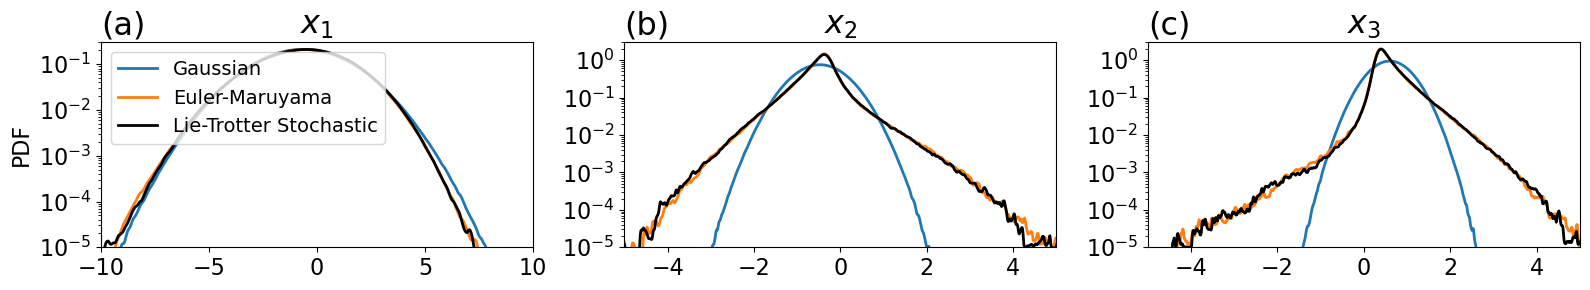

In [67]:
fig = plt.figure(figsize=(16,3))

fontsize_title = 23
linewidth = 2


ax = plt.subplot(131)
i = 0
plt.plot(x_Gauss[i], y_Gauss[i], '-', label='Gaussian', linewidth=linewidth)
plt.plot(x_em[i], y_em[i], '-', label='Euler-Maruyama', linewidth=linewidth)
plt.plot(x_lt[i], y_lt[i], '-', color='k', label='Lie-Trotter Stochastic', linewidth=linewidth)

plt.yscale('log')
plt.xlim(-10, 10)
plt.ylim(1e-5, 0.3)

plt.locator_params(axis='x', nbins=5)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel('PDF', fontsize=16)
        
plt.title('$x_1$', fontsize=fontsize_title)
plt.title('(a)', loc='left', fontsize=fontsize_title)
plt.legend(fontsize=14, loc='upper left') # <-- Added legend


ax = plt.subplot(132)
i = 1
plt.plot(x_Gauss[i], y_Gauss[i], '-', label='Gaussian', linewidth=linewidth)
plt.plot(x_em[i], y_em[i], '-', label='Euler-M.', linewidth=linewidth)
plt.plot(x_lt[i], y_lt[i], '-', color='k', label='Lie-Trotter Stoch.', linewidth=linewidth)

plt.yscale('log')
#plt.xlim(-6, 6)
plt.xlim(-5, 5)
plt.ylim(1e-5, 3)

plt.locator_params(axis='x', nbins=5)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
        
plt.title('$x_2$', fontsize=fontsize_title)
plt.title('(b)', loc='left', fontsize=fontsize_title)


ax = plt.subplot(133)
i = 2
plt.plot(x_Gauss[i], y_Gauss[i], '-', label='Gaussian', linewidth=linewidth)
plt.plot(x_em[i], y_em[i], '-', label='Euler-M.', linewidth=linewidth)
plt.plot(x_lt[i], y_lt[i], '-', color='k', label='Lie-Trotter Stoch.', linewidth=linewidth)

plt.yscale('log')
plt.xlim(-5, 5)
plt.ylim(1e-5, 3)

plt.locator_params(axis='x', nbins=5)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
        
plt.title('$x_3$', fontsize=fontsize_title)
plt.title('(c)', loc='left', fontsize=fontsize_title)

plt.tight_layout()
plt.show()

fig.savefig('./figures/triad_models_PDFs.pdf',bbox_inches='tight')